# Delamanid: how the signal changes under progressive adjustment

> **What the numbers show.** As lineage and then resistance type are added as adjustment variables, no single mutation's edge into the delamanid MIC stays above the 0.5 bar. The apparent lineage and type edges do not survive the corrected orientation; the remaining signal sits with the efflux-cluster mutations. Interpretation is left to the reader.

This notebook compares the **numbers** across adjustment conditions (baseline, +lineage, +lineage +type, and type adjusted out): how each mutation's reliability score into `dlm_mic` moves as variables are added. The graph pictures are in [delamanid_stable_graphs.ipynb](delamanid_stable_graphs.ipynb); the adjustment conditions and the orientation choices behind them are described in [README.md](README.md).

Read: an edge that reflects a genuine direct input keeps its score into `dlm_mic` as adjustment variables are added; an artifact fades.

In [1]:
import sys, warnings; from pathlib import Path
warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parents[2]))
from src.causal_discovery.cmm_utils import show_graph, parents_of, parents_across, plot_parents_across, plot_parents_panels
LINFIX = 'tb_subsampling_dlm_mp4_k6_mcc4_linfix'
CONDS = {'baseline': f'{LINFIX}/baseline', '+lineage': f'{LINFIX}/with_lineage', '+lineage+type': f'{LINFIX}/with_lineage_and_type', 'type adj. out': f'{LINFIX}/with_lineage_and_type_forbid_type_to_mic'}

## Reliability score into dlm_mic across conditions

One panel per condition, in order. Each arrow is a feature pointing into the delamanid MIC, with width proportional to how often that edge survives the subsampling (dark blue at or above the 0.5 bar). Reading left to right shows how the drivers evolve as lineage and then resistance type are adjusted for.

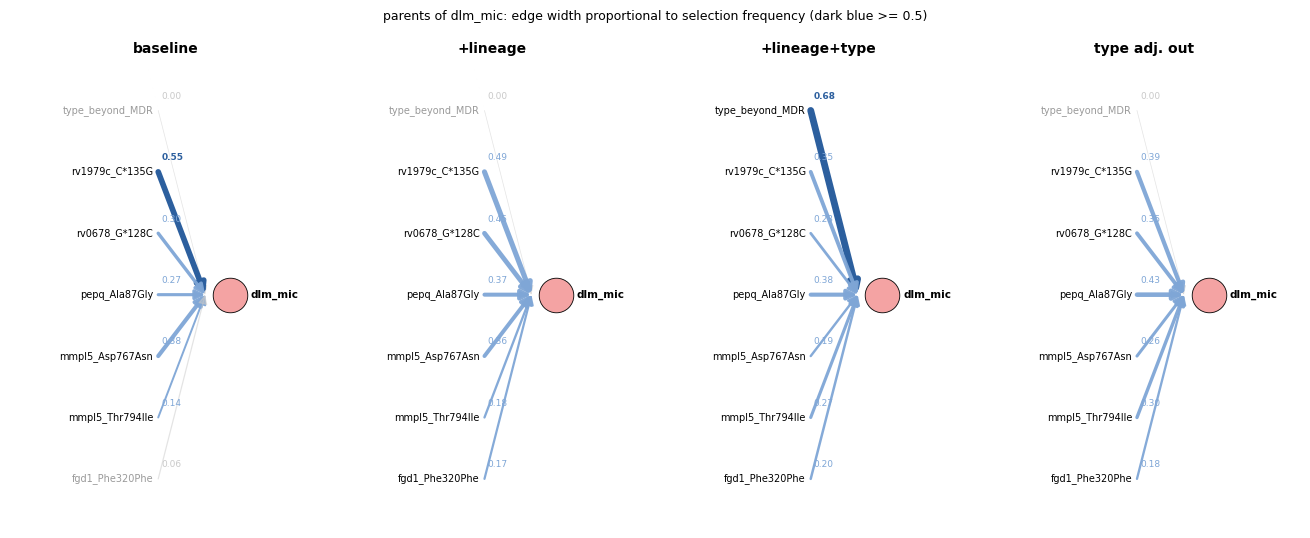

In [2]:
plot_parents_panels(CONDS, 'dlm_mic')

In [3]:
parents_across(CONDS, 'dlm_mic')

,baseline,+lineage,+lineage+type,type adj. out
source,,,,
pepq_Ala87Gly,0.27,0.37,0.38,0.43
rv1979c_C*135G,0.55,0.49,0.35,0.39
rv0678_G*128C,0.30,0.45,0.23,0.35
mmpl5_Thr794Ile,0.14,0.18,0.27,0.30
mmpl5_Asp767Asn,0.38,0.36,0.19,0.26
fgd1_G*357C,0.17,0.14,0.19,0.18
fgd1_Phe320Phe,0.06,0.17,0.20,0.18
lineage_2,0.00,0.10,0.10,0.10
lineage_4,0.00,0.15,0.10,0.10


## What changed

Reading the panels left to right:

- **baseline**: a few mutations look linked, and `rv1979c_C*135G` clears the 0.5 bar.
- **+lineage**: adding lineage pulls every mutation edge below 0.5. The shared signal these mutations carried is absorbed once lineage is in the graph.
- **+lineage +type**: when resistance type is allowed to point into the MIC it dominates (~0.68) and suppresses the mutation edges. Delamanid is not part of what defines the type label, so that edge reflects the adjustment choice, not a direct input to the MIC.
- **type adj. out**: with type forbidden into the MIC, the signal returns to the mutations (`pepq_Ala87Gly` leads at 0.43), but none reaches 0.5.

Under the strictest adjustment no single mutation clears 0.5, so the cautious read stands. What moves across conditions is where the signal is attributed: the efflux-cluster mutations and `pepq_Ala87Gly`, not lineage or type.